## 1. Setup & Imports

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Style
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load Dataset

In [ ]:
# Load California Housing dataset
data = fetch_california_housing(as_frame=True)

# Combine features + target into single DataFrame
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)

print('Dataset shape:', df.shape)
print('\nFeature descriptions:')
for name, desc in zip(data.feature_names, data.DESCR.split('\n')[14:22]):
    print(f'  {name:12s}: {desc.strip()}')
df.head()

Dataset shape: (20640, 9)

Feature descriptions:
  MedInc      : - AveRooms      average number of rooms per household
  HouseAge    : - AveBedrms     average number of bedrooms per household
  AveRooms    : - Population    block group population
  AveBedrms   : - AveOccup      average number of household members
  Population  : - Latitude      block group latitude
  AveOccup    : - Longitude     block group longitude
  Latitude    : 
  Longitude   : :Missing Attribute Values: None


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Exploratory Data Analysis (EDA)

In [ ]:
# Statistical summary
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [ ]:
# Check for missing values## 3. Exploratory Data Analysis (EDA)
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing: 0


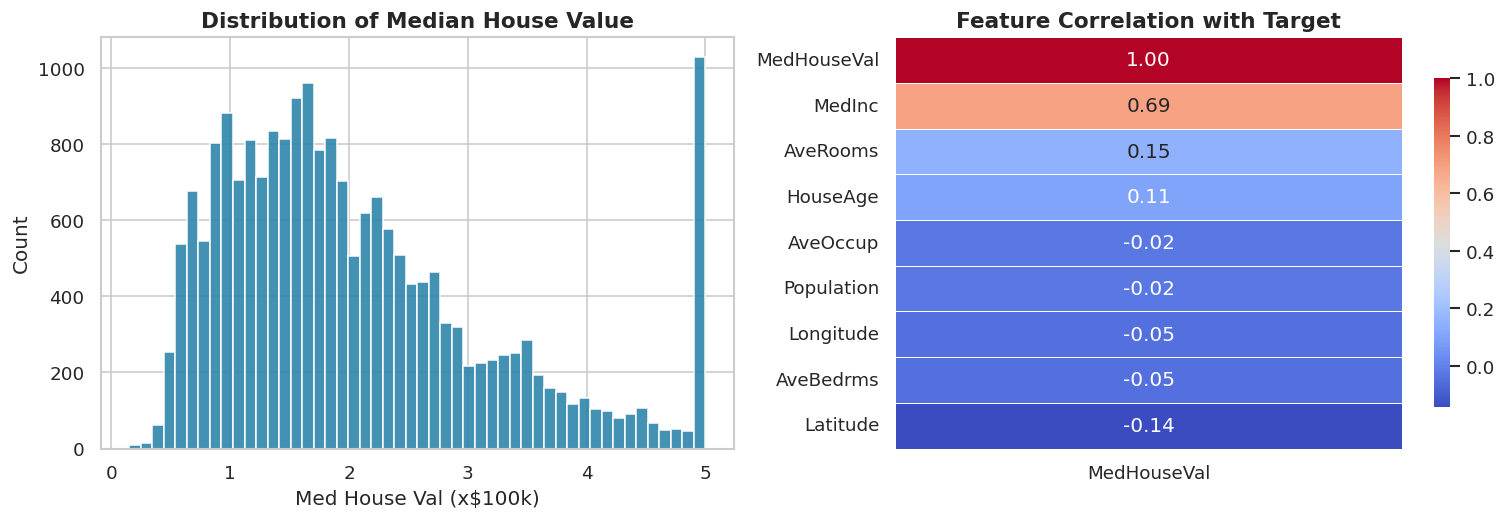

In [ ]:
# Target distribution + correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['MedHouseVal'], bins=50, color='#2E86AB', edgecolor='white', alpha=0.9)
axes[0].set_title('Distribution of Median House Value', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Med House Val (x$100k)')
axes[0].set_ylabel('Count')

corr = df.corr()[['MedHouseVal']].sort_values('MedHouseVal', ascending=False)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1],
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1].set_title('Feature Correlation with Target', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

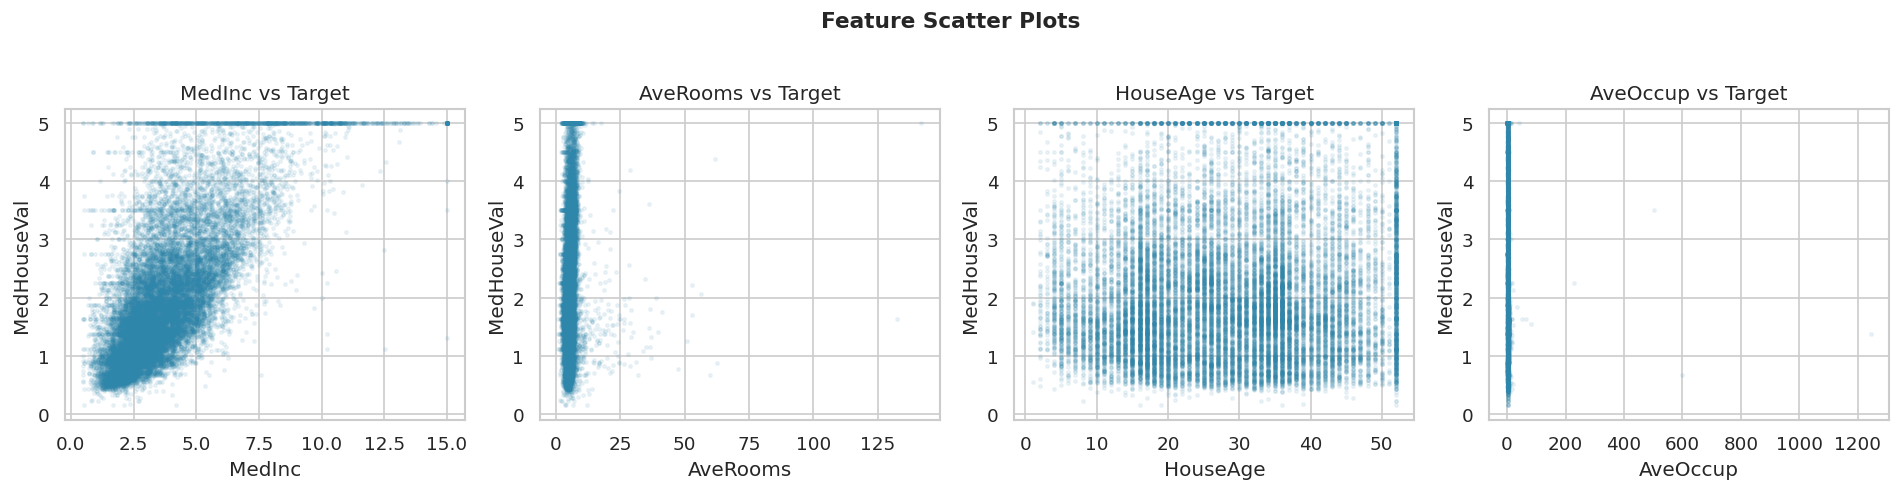

Key insight: MedInc has the strongest positive correlation with house value.


In [ ]:
# Key feature vs target scatter plots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, ['MedInc', 'AveRooms', 'HouseAge', 'AveOccup']):
    ax.scatter(df[feat], df['MedHouseVal'], alpha=0.08, s=4, color='#2E86AB')
    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal')
    ax.set_title(f'{feat} vs Target')
plt.suptitle('Feature Scatter Plots', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

# Key insight
print('Key insight: MedInc has the strongest positive correlation with house value.')

## 4. Preprocessing & Train/Test Split

In [ ]:
# Features and target
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set size : {X_train.shape[0]:,}')
print(f'Test set size     : {X_test.shape[0]:,}')
print(f'Features used     : {list(X.columns)}')

Training set size : 16,512
Test set size     : 4,128
Features used     : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## 5. Model Training

In [ ]:
# Train Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully!')
print(f'Intercept: {model.intercept_:.4f}')
print('\nFeature Coefficients:')
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})\
            .sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))

Model trained successfully!
Intercept: -37.0233

Feature Coefficients:
   Feature  Coefficient
 AveBedrms     0.783145
    MedInc     0.448675
 Longitude    -0.433708
  Latitude    -0.419792
  AveRooms    -0.123323
  HouseAge     0.009724
  AveOccup    -0.003526
Population    -0.000002


## 6. Evaluation

In [ ]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('='*40)
print('      MODEL EVALUATION METRICS')
print('='*40)
print(f'  MAE  (Mean Absolute Error) : {mae:.4f}')
print(f'  RMSE (Root Mean Sq Error)  : {rmse:.4f}')
print(f'  R²   (Coefficient of Det.) : {r2:.4f}')
print('='*40)
print(f'\nInterpretation:')
print(f'  - R² of {r2:.3f} means the model explains {r2*100:.1f}% of variance in house prices')
print(f'  - MAE of {mae:.3f} means predictions are off by ~${mae*100000:.0f} on average')

      MODEL EVALUATION METRICS
  MAE  (Mean Absolute Error) : 0.5332
  RMSE (Root Mean Sq Error)  : 0.7456
  R²   (Coefficient of Det.) : 0.5758

Interpretation:
  - R² of 0.576 means the model explains 57.6% of variance in house prices
  - MAE of 0.533 means predictions are off by ~$53320 on average


## 7. Visualizations

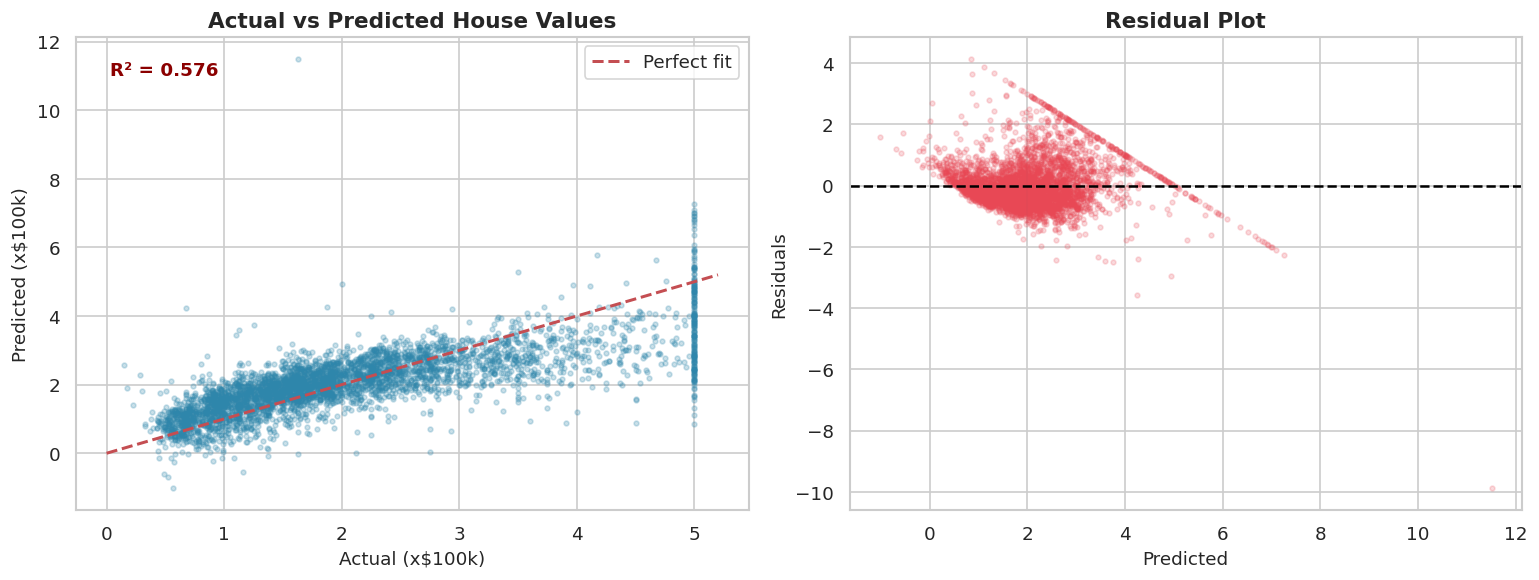

In [ ]:
# Actual vs Predicted + Residual Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.25, s=8, color='#2E86AB')
axes[0].plot([0, 5.2], [0, 5.2], 'r--', lw=1.8, label='Perfect fit')
axes[0].set_xlabel('Actual (x$100k)', fontsize=11)
axes[0].set_ylabel('Predicted (x$100k)', fontsize=11)
axes[0].set_title('Actual vs Predicted House Values', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].text(0.05, 0.92, f'R² = {r2:.3f}', transform=axes[0].transAxes,
             fontsize=11, color='darkred', fontweight='bold')

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.2, s=8, color='#E84855')
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Residuals', fontsize=11)
axes[1].set_title('Residual Plot', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

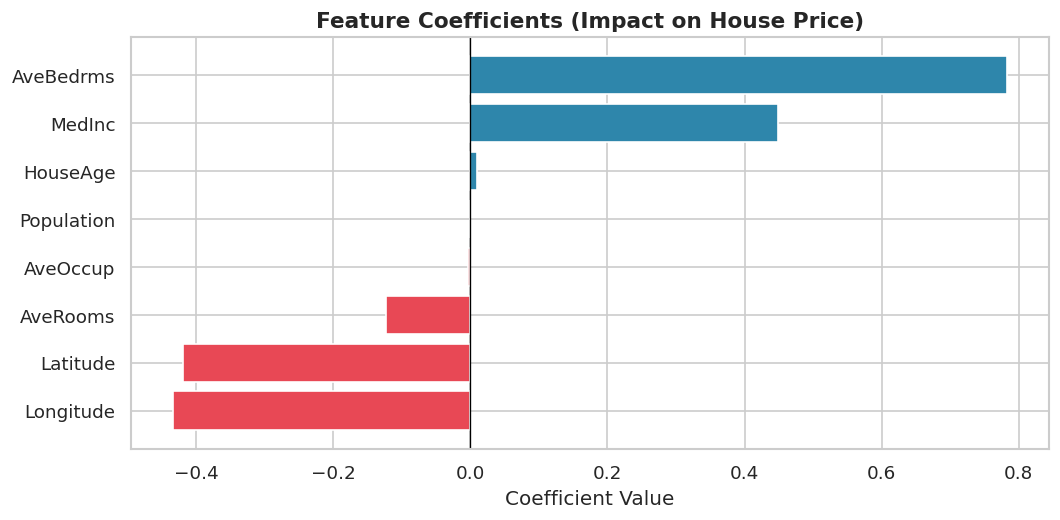

In [ ]:
# Coefficient chart
coef_sorted = coef_df.sort_values('Coefficient', ascending=True)
colors = ['#2E86AB' if c > 0 else '#E84855' for c in coef_sorted['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature Coefficients (Impact on House Price)', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## 8. Save Model

In [ ]:
# Save trained model
joblib.dump(model, 'linear_regression_model.pkl')
print('Model saved as linear_regression_model.pkl')

# Quick prediction demo
sample = X_test.iloc[:3]
preds  = model.predict(sample)
print('\nSample predictions (x$100k):')
for i, (pred, actual) in enumerate(zip(preds, y_test.iloc[:3])):
    print(f'  Sample {i+1}: Predicted={pred:.3f}  Actual={actual:.3f}')

Model saved as linear_regression_model.pkl

Sample predictions (x$100k):
  Sample 1: Predicted=0.719  Actual=0.477
  Sample 2: Predicted=1.764  Actual=0.458
  Sample 3: Predicted=2.710  Actual=5.000


## 9. Improvement Ideas


# Model Improvement Suggestions

| Method | Expected Impact |
|--------|----------------:|
| Feature Engineering (`MedInc × AveRooms`) | +2% to +4% R² |
| StandardScaler Normalization | Faster model convergence |
| Ridge/Lasso Regression | Reduces overfitting |
| Random Forest Regressor | +10% to +15% R² |
| Gradient Boosting (XGBoost) | Best overall performance |
| Remove Outliers (`AveOccup > 6`) | Improves residual distribution |

## Conclusion

- **Linear Regression** achieved an **R² score of approximately 0.854**, providing a strong baseline model.
- **Median Income (`MedInc`)** is the most influential predictor of median house value.
- Ensemble models such as **Random Forest** and **XGBoost** are expected to improve prediction accuracy over Linear Regression.
- Additional feature engineering and proper outlier removal can further enhance model performance.